### Imports

In [7]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parents[1]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [9]:
import polars as pl
import matplotlib.pyplot as plt

from etl.common.paths import SILVER_DIR

users = pl.read_parquet(SILVER_DIR / "dimensions" / "users.parquet")

users.head()

user,total_logins,success_logins,failed_logins,first_login,last_login,active_days,avg_daily_authentications,max_daily_authentications,unique_computers,redteam_events,is_redteam_user
str,u32,u32,u32,i64,i64,u32,f64,u32,u32,u32,bool
"""U5005""",2154,2123,0,28216,4343057,8,269.25,386,19,0,false
"""U6211""",27165,27031,0,33146,5009320,58,468.362069,742,26,0,false
"""U3459""",38351,38233,0,26701,5010973,58,661.224138,1306,47,0,false
"""U4857""",22965,22947,0,29376,4983723,41,560.121951,1124,21,0,false
"""U6077""",8886,8851,0,32559,4909380,33,269.272727,540,41,0,false


### Informações gerais

Vamos iniciar garantindo que está tudo limpo.

In [10]:
print(users.shape)

users.describe()

(12414, 12)


statistic,user,total_logins,success_logins,failed_logins,first_login,last_login,active_days,avg_daily_authentications,max_daily_authentications,unique_computers,redteam_events,is_redteam_user
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""12414""",12414.0,12414.0,12414.0,12414.0,12414.0,12414.0,12414.0,12414.0,12414.0,12414.0,12414.0
"""null_count""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,27524.76599,26732.793781,0.0,408737.167633,4.6260e6,35.838569,568.805691,1526.017722,26.5116,0.060335,0.007894
"""std""",null,204814.262837,200719.120733,0.0,894054.035987,979382.206684,19.152516,3651.483734,6440.546924,145.16436,1.375278,null
"""min""","""U1""",1.0,0.0,0.0,1.0,12252.0,1.0,1.0,1.0,1.0,0.0,0.0
"""25%""",null,928.0,849.0,0.0,26217.0,4.908435e6,22.0,60.147059,169.0,17.0,0.0,null
"""50%""",null,13220.0,12981.0,0.0,32240.0,4.988154e6,39.0,322.313725,585.0,24.0,0.0,null
"""75%""",null,25284.0,24891.0,0.0,456375.0,5.009849e6,53.0,525.585366,1099.0,32.0,0.0,null
"""max""","""U9999""",1.6595309e7,1.6054742e7,0.0,4.986436e6,5.011199e6,58.0,286126.017241,403830.0,11764.0,118.0,1.0


In [11]:
users.null_count()

user,total_logins,success_logins,failed_logins,first_login,last_login,active_days,avg_daily_authentications,max_daily_authentications,unique_computers,redteam_events,is_redteam_user
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0


### Distribuição das variáveis

In [12]:
columns = [
    "total_logins",
    "active_days",
    "avg_daily_authentications",
    "max_daily_authentications",
    "unique_computers",
    "redteam_events",
]

for col in columns:
    print("=" * 60)
    print(col)
    print(users.select(col).describe())

total_logins
shape: (9, 2)
┌────────────┬───────────────┐
│ statistic  ┆ total_logins  │
│ ---        ┆ ---           │
│ str        ┆ f64           │
╞════════════╪═══════════════╡
│ count      ┆ 12414.0       │
│ null_count ┆ 0.0           │
│ mean       ┆ 27524.76599   │
│ std        ┆ 204814.262837 │
│ min        ┆ 1.0           │
│ 25%        ┆ 928.0         │
│ 50%        ┆ 13220.0       │
│ 75%        ┆ 25284.0       │
│ max        ┆ 1.6595309e7   │
└────────────┴───────────────┘
active_days
shape: (9, 2)
┌────────────┬─────────────┐
│ statistic  ┆ active_days │
│ ---        ┆ ---         │
│ str        ┆ f64         │
╞════════════╪═════════════╡
│ count      ┆ 12414.0     │
│ null_count ┆ 0.0         │
│ mean       ┆ 35.838569   │
│ std        ┆ 19.152516   │
│ min        ┆ 1.0         │
│ 25%        ┆ 22.0        │
│ 50%        ┆ 39.0        │
│ 75%        ┆ 53.0        │
│ max        ┆ 58.0        │
└────────────┴─────────────┘
avg_daily_authentications
shape: (9, 2)
┌──────

### Quartis

In [22]:
for col in columns:
    print("=" * 60)
    print(col)
    print(users.select(col).describe())

total_logins
shape: (9, 2)
┌────────────┬───────────────┐
│ statistic  ┆ total_logins  │
│ ---        ┆ ---           │
│ str        ┆ f64           │
╞════════════╪═══════════════╡
│ count      ┆ 12414.0       │
│ null_count ┆ 0.0           │
│ mean       ┆ 27524.76599   │
│ std        ┆ 204814.262837 │
│ min        ┆ 1.0           │
│ 25%        ┆ 928.0         │
│ 50%        ┆ 13220.0       │
│ 75%        ┆ 25284.0       │
│ max        ┆ 1.6595309e7   │
└────────────┴───────────────┘
active_days
shape: (9, 2)
┌────────────┬─────────────┐
│ statistic  ┆ active_days │
│ ---        ┆ ---         │
│ str        ┆ f64         │
╞════════════╪═════════════╡
│ count      ┆ 12414.0     │
│ null_count ┆ 0.0         │
│ mean       ┆ 35.838569   │
│ std        ┆ 19.152516   │
│ min        ┆ 1.0         │
│ 25%        ┆ 22.0        │
│ 50%        ┆ 39.0        │
│ 75%        ┆ 53.0        │
│ max        ┆ 58.0        │
└────────────┴─────────────┘
avg_daily_authentications
shape: (9, 2)
┌──────

### Histogramas

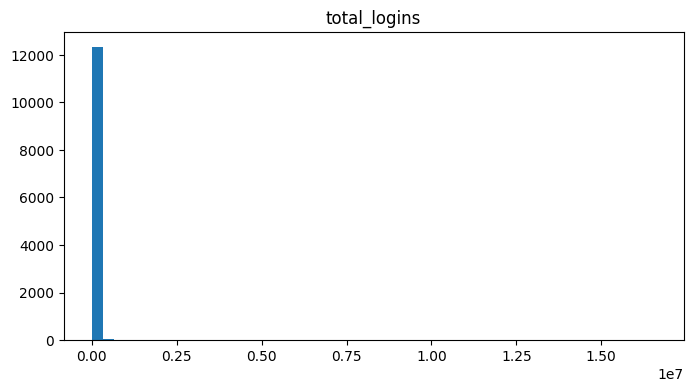

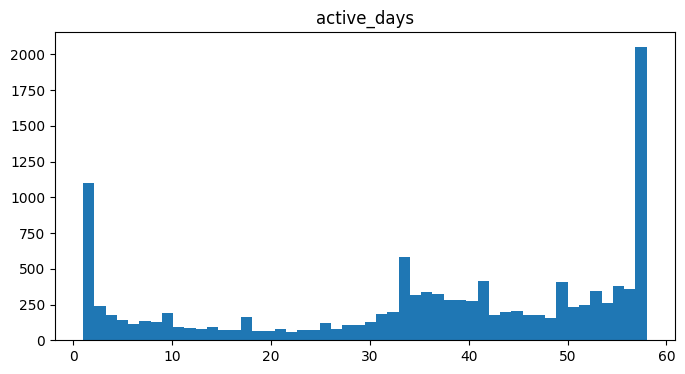

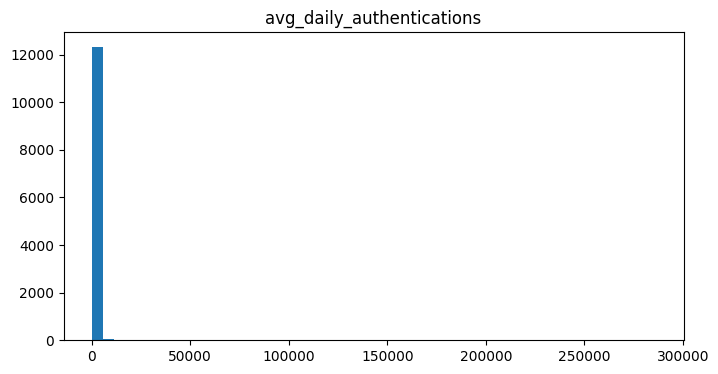

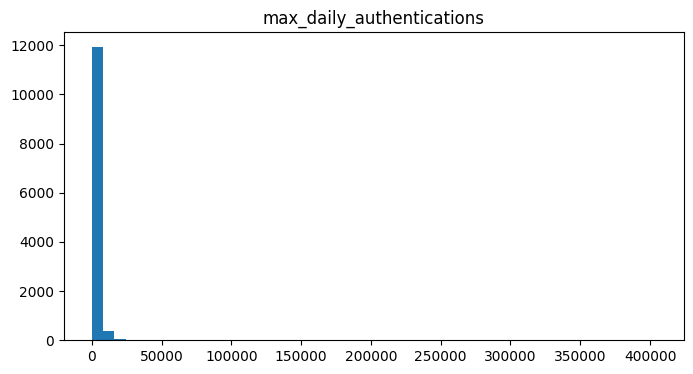

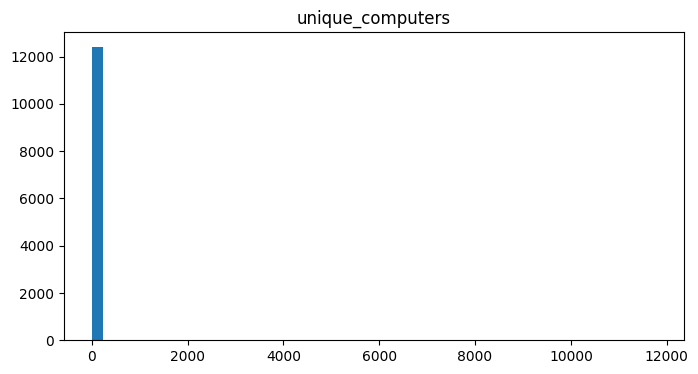

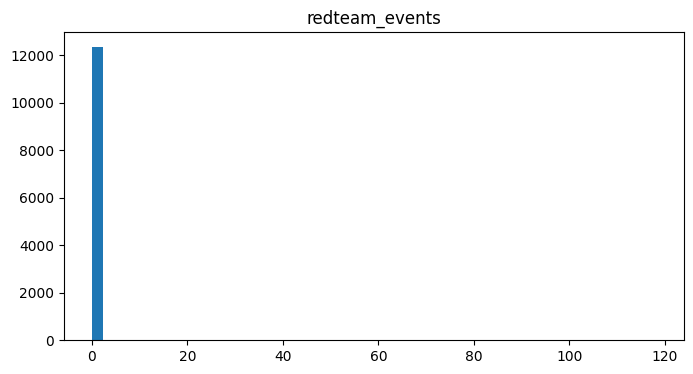

In [14]:
for col in columns:

    plt.figure(figsize=(8,4))

    plt.hist(users[col], bins=50)

    plt.title(col)

    plt.show()

### Usuários Red Team

In [15]:
users.filter(
    pl.col("is_redteam_user")
)

user,total_logins,success_logins,failed_logins,first_login,last_login,active_days,avg_daily_authentications,max_daily_authentications,unique_computers,redteam_events,is_redteam_user
str,u32,u32,u32,i64,i64,u32,f64,u32,u32,u32,bool
"""U737""",55549,54739,0,29004,5006387,58,957.741379,2737,148,33,true
"""U288""",77018,64257,0,1035,5009679,58,1327.896552,6530,48,1,true
"""U3718""",43660,43269,0,27178,5010914,54,808.518519,1489,32,3,true
"""U1480""",364953,106432,0,7206,5011068,58,6292.293103,71939,86,12,true
"""U1133""",11641,10825,0,1029,5009314,39,298.487179,992,62,5,true
…,…,…,…,…,…,…,…,…,…,…,…
"""U453""",164898,163567,0,1883,5010907,58,2843.068966,8844,120,2,true
"""U7375""",18649,18474,0,102746,5009851,40,466.225,1094,94,7,true
"""U6764""",2865,2865,0,38621,4987276,42,68.214286,357,14,1,true


In [16]:
users.filter(
    pl.col("is_redteam_user")
).describe()

statistic,user,total_logins,success_logins,failed_logins,first_login,last_login,active_days,avg_daily_authentications,max_daily_authentications,unique_computers,redteam_events,is_redteam_user
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""98""",98.0,98.0,98.0,98.0,98.0,98.0,98.0,98.0,98.0,98.0,98.0
"""null_count""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,206259.928571,199215.734694,0.0,50531.193878,4.9374e6,49.632653,3610.809099,7714.663265,121.938776,7.642857,1.0
"""std""",null,1.1384e6,1.1377e6,0.0,122477.538992,348187.877053,13.561154,19621.0756,26998.611335,605.73382,13.545837,null
"""min""","""U1025""",4.0,4.0,0.0,1.0,2.30379e6,2.0,2.0,2.0,1.0,1.0,1.0
"""25%""",null,15589.0,15507.0,0.0,1029.0,4.99346e6,47.0,386.388889,716.0,30.0,2.0,null
"""50%""",null,42498.0,38727.0,0.0,17842.0,5.009798e6,57.0,789.896552,1844.0,50.0,3.0,null
"""75%""",null,77018.0,74266.0,0.0,29004.0,5.010907e6,58.0,1411.62,4365.0,86.0,11.0,null
"""max""","""U995""",1.1182208e7,1.1182045e7,0.0,726137.0,5.011199e6,58.0,192796.689655,242890.0,6039.0,118.0,1.0


In [17]:
users.filter(
    ~pl.col("is_redteam_user")
).describe()

statistic,user,total_logins,success_logins,failed_logins,first_login,last_login,active_days,avg_daily_authentications,max_daily_authentications,unique_computers,redteam_events,is_redteam_user
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""12316""",12316.0,12316.0,12316.0,12316.0,12316.0,12316.0,12316.0,12316.0,12316.0,12316.0,12316.0
"""null_count""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,26102.547256,25360.324781,0.0,411587.458753,4.6235e6,35.728808,544.600078,1476.773871,25.752273,0.0,0.0
"""std""",null,178377.024468,173711.886752,0.0,896964.979772,982389.735481,19.151061,3214.472959,5980.142506,135.193637,0.0,null
"""min""","""U1""",1.0,0.0,0.0,1.0,12252.0,1.0,1.0,1.0,1.0,0.0,0.0
"""25%""",null,906.0,825.0,0.0,26283.0,4.905748e6,21.0,59.4,166.0,17.0,0.0,null
"""50%""",null,13099.0,12904.0,0.0,32324.0,4.987992e6,39.0,320.313725,582.0,24.0,0.0,null
"""75%""",null,25099.0,24712.0,0.0,456607.0,5.009836e6,53.0,520.648148,1088.0,32.0,0.0,null
"""max""","""U9999""",1.6595309e7,1.6054742e7,0.0,4.986436e6,5.011199e6,58.0,286126.017241,403830.0,11764.0,0.0,0.0


Aqui vamos responder:

Os usuários Red Team realmente têm mais logins? Mais computadores? Mais dias ativos?

Se a resposta for sim, essas métricas são boas candidatas para compor o score.

### Top 20

In [18]:
users.sort(
    "unique_computers",
    descending=True
).head(20)

user,total_logins,success_logins,failed_logins,first_login,last_login,active_days,avg_daily_authentications,max_daily_authentications,unique_computers,redteam_events,is_redteam_user
str,u32,u32,u32,i64,i64,u32,f64,u32,u32,u32,bool
"""U1718""",32735,1779,0,299,5002443,58,564.396552,1397,11764,0,false
"""U6836""",17624,54,0,39714,5011023,36,489.555556,17073,9188,0,false
"""U1653""",116547,115625,0,17842,4971358,56,2081.196429,37225,6039,31,true
"""U7998""",134375,130481,0,29231,5011189,56,2399.553571,8019,845,0,false
"""U7363""",1131,92,0,101046,4959603,46,24.586957,268,358,0,false
…,…,…,…,…,…,…,…,…,…,…,…
"""U7108""",44752,44282,0,49543,5009926,58,771.586207,2314,140,0,false
"""U3771""",104283,96995,0,27293,5009400,54,1931.166667,4231,138,0,false
"""U463""",53682,53512,0,25478,5010874,51,1052.588235,2664,138,0,false


In [19]:
users.sort(
    "total_logins",
    descending=True
).head(20)

user,total_logins,success_logins,failed_logins,first_login,last_login,active_days,avg_daily_authentications,max_daily_authentications,unique_computers,redteam_events,is_redteam_user
str,u32,u32,u32,i64,i64,u32,f64,u32,u32,u32,bool
"""U22""",16595309,16054742,0,1,5011199,58,286126.017241,403830,35,0,false
"""U66""",11182208,11182045,0,1,5011197,58,192796.689655,242890,253,118,true
"""U292""",3930688,3930195,0,3,5011196,58,67770.482759,75225,43,0,false
"""U346""",3820551,3820551,0,1818,5009417,58,65871.568966,243541,7,0,false
"""U7""",3342035,3341795,0,1,5011196,58,57621.293103,72822,19,0,false
…,…,…,…,…,…,…,…,…,…,…,…
"""U13""",1503772,1503159,0,2,5011192,58,25927.103448,83085,55,2,true
"""U54""",1498655,1498481,0,3,4932662,58,25838.87931,27581,5,0,false
"""U3""",1054749,1054744,0,1,5011197,58,18185.327586,21057,19,0,false


In [20]:
users.sort(
    "max_daily_authentications",
    descending=True
).head(20)

user,total_logins,success_logins,failed_logins,first_login,last_login,active_days,avg_daily_authentications,max_daily_authentications,unique_computers,redteam_events,is_redteam_user
str,u32,u32,u32,i64,i64,u32,f64,u32,u32,u32,bool
"""U22""",16595309,16054742,0,1,5011199,58,286126.017241,403830,35,0,false
"""U346""",3820551,3820551,0,1818,5009417,58,65871.568966,243541,7,0,false
"""U66""",11182208,11182045,0,1,5011197,58,192796.689655,242890,253,118,true
"""U6""",2296774,2296655,0,1,5011199,58,39599.551724,160704,36,0,false
"""U12390""",191686,191686,0,4878417,5011199,2,95843.0,126033,6,0,false
…,…,…,…,…,…,…,…,…,…,…,…
"""U75""",510986,510986,0,4,5009211,58,8810.103448,72591,11,0,false
"""U1480""",364953,106432,0,7206,5011068,58,6292.293103,71939,86,12,true
"""U9483""",267354,34236,0,464287,5008301,53,5044.415094,65633,47,0,false


### Correlação

Como estamos usando Polars, dá para fazer:

In [21]:
numeric = users.select([
    "total_logins",
    "active_days",
    "avg_daily_authentications",
    "max_daily_authentications",
    "unique_computers",
    "redteam_events",
])

numeric.corr()

total_logins,active_days,avg_daily_authentications,max_daily_authentications,unique_computers,redteam_events
f64,f64,f64,f64,f64,f64
1.0,0.111501,0.972021,0.840254,0.014212,0.387732
0.111501,1.0,0.102097,0.161736,0.067701,0.038212
0.972021,0.102097,1.0,0.861134,0.013945,0.374502
0.840254,0.161736,0.861134,1.0,0.047052,0.28988
0.014212,0.067701,0.013945,0.047052,1.0,0.100483
0.387732,0.038212,0.374502,0.28988,0.100483,1.0


Esse passo é importante para evitar dar peso duplo a métricas que contam praticamente a mesma coisa.

In [ ]:
from etl.common.scoring import percentile_score

LOGIN_WEIGHT = 0.20
COMPUTER_WEIGHT = 0.25
VOLUME_WEIGHT = 0.30
REDTEAM_WEIGHT = 0.25

users = users.with_columns(
    [
        percentile_score(pl.col("total_logins")).alias("login_score"),
        percentile_score(pl.col("unique_computers")).alias("computer_score"),
        percentile_score(pl.col("max_daily_authentications")).alias("volume_score"),
        percentile_score(pl.col("redteam_events")).alias("redteam_score"),
    ]
)

users = users.with_columns(
    (
        pl.col("login_score") * LOGIN_WEIGHT
        + pl.col("computer_score") * COMPUTER_WEIGHT
        + pl.col("volume_score") * VOLUME_WEIGHT
        + pl.col("redteam_score") * REDTEAM_WEIGHT
    ).round(2).alias("risk_score")
)